# Phase 7: Final Results Compilation
---
**Purpose:** Consolidate model performance, cross-validation, and comparative results into publication-ready tables and figures. All numeric results are loaded directly from the CSVs generated by Phase 5 and Phase 6 to guarantee consistency between the computational pipeline and the thesis narrative.  

**Inputs:** `phase5_final_results.csv`, `phase6_cv_detailed_results.csv`  
**Outputs:** `final_model_results.csv`, `final_model_results.tex`, `final_results_figure.png`

## 7.1 Setup

In [1]:
!pip install -q pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

## 7.2 Load Phase 5 and Phase 6 Results

In [2]:
# Results are computed — never hardcoded. Upload the CSVs saved by Phase 5 and Phase 6.
print('Upload both:')
print('  - phase5_final_results.csv (from Phase 5)')
print('  - phase6_cv_detailed_results.csv (from Phase 6)')
uploaded = files.upload()

phase5_file = [f for f in uploaded if 'phase5' in f.lower() and 'final' in f.lower()][0]
phase6_file = [f for f in uploaded if 'phase6' in f.lower() and 'cv' in f.lower()][0]

phase5 = pd.read_csv(phase5_file)
phase6 = pd.read_csv(phase6_file)

print(f'\nPhase 5 results ({len(phase5)} rows):')
print(phase5.to_string(index=False))
print(f'\nPhase 6 CV results ({len(phase6)} rows):')
print(phase6.head(12).to_string(index=False))

Upload both:
  - phase5_final_results.csv (from Phase 5)
  - phase6_cv_detailed_results.csv (from Phase 6)


Saving phase5_final_results (1).csv to phase5_final_results (1).csv
Saving phase6_cv_detailed_results (6).csv to phase6_cv_detailed_results (6).csv

Phase 5 results (6 rows):
      MOH    Model        AIC      MAE     RMSE        R2
Balangoda Baseline 756.531844 1.857671 2.487764 -0.167339
Balangoda    NB-AR 706.373903 1.574596 2.272156  0.026233
Balangoda    Naive        NaN 2.000000 2.773501 -0.450893
Udawalawa Baseline 496.000847 1.295207 2.249902 -0.120207
Udawalawa    NB-AR 492.614293 1.410393 2.599256 -0.495096
Udawalawa    Naive        NaN 1.461538 2.935198 -0.906539

Phase 6 CV results (10 rows):
      MOH  Fold       MAE       RMSE           R2  Train_n  Test_n
Balangoda     1  1.025174   1.469014    -0.241996       46      42
Balangoda     2 53.828856 234.288798 -1249.686498       88      42
Balangoda     3  1.535984   2.105029    -0.419126      130      42
Balangoda     4  1.684636   2.396075    -0.032043      172      42
Balangoda     5  1.523259   2.028058     0.090008    

## 7.3 Final Model Comparison Table

In [3]:
# Extract the Baseline and NB-AR rows (naive is also in the CSV for reference)
results = phase5[phase5['Model'].isin(['Baseline','NB-AR'])].copy()
results = results.sort_values(['MOH','Model'])

print('Final Model Comparison Table:')
print(results.round(3).to_string(index=False))

# Save clean copies in multiple formats for the thesis
results.to_csv('final_model_results.csv', index=False)
try:
    results.to_latex('final_model_results.tex', index=False,
                     caption='Negative Binomial Model Performance Comparison',
                     label='tab:model_results', float_format='%.3f')
    print('\nSaved: final_model_results.csv and final_model_results.tex')
except Exception as e:
    results.to_csv('final_model_results_for_tex.csv', index=False)
    print(f'\nSaved: final_model_results.csv (LaTeX export not available: {e})')

Final Model Comparison Table:
      MOH    Model     AIC   MAE  RMSE     R2
Balangoda Baseline 756.532 1.858 2.488 -0.167
Balangoda    NB-AR 706.374 1.575 2.272  0.026
Udawalawa Baseline 496.001 1.295 2.250 -0.120
Udawalawa    NB-AR 492.614 1.410 2.599 -0.495

Saved: final_model_results.csv and final_model_results.tex


## 7.4 Publication Figure — Model Performance

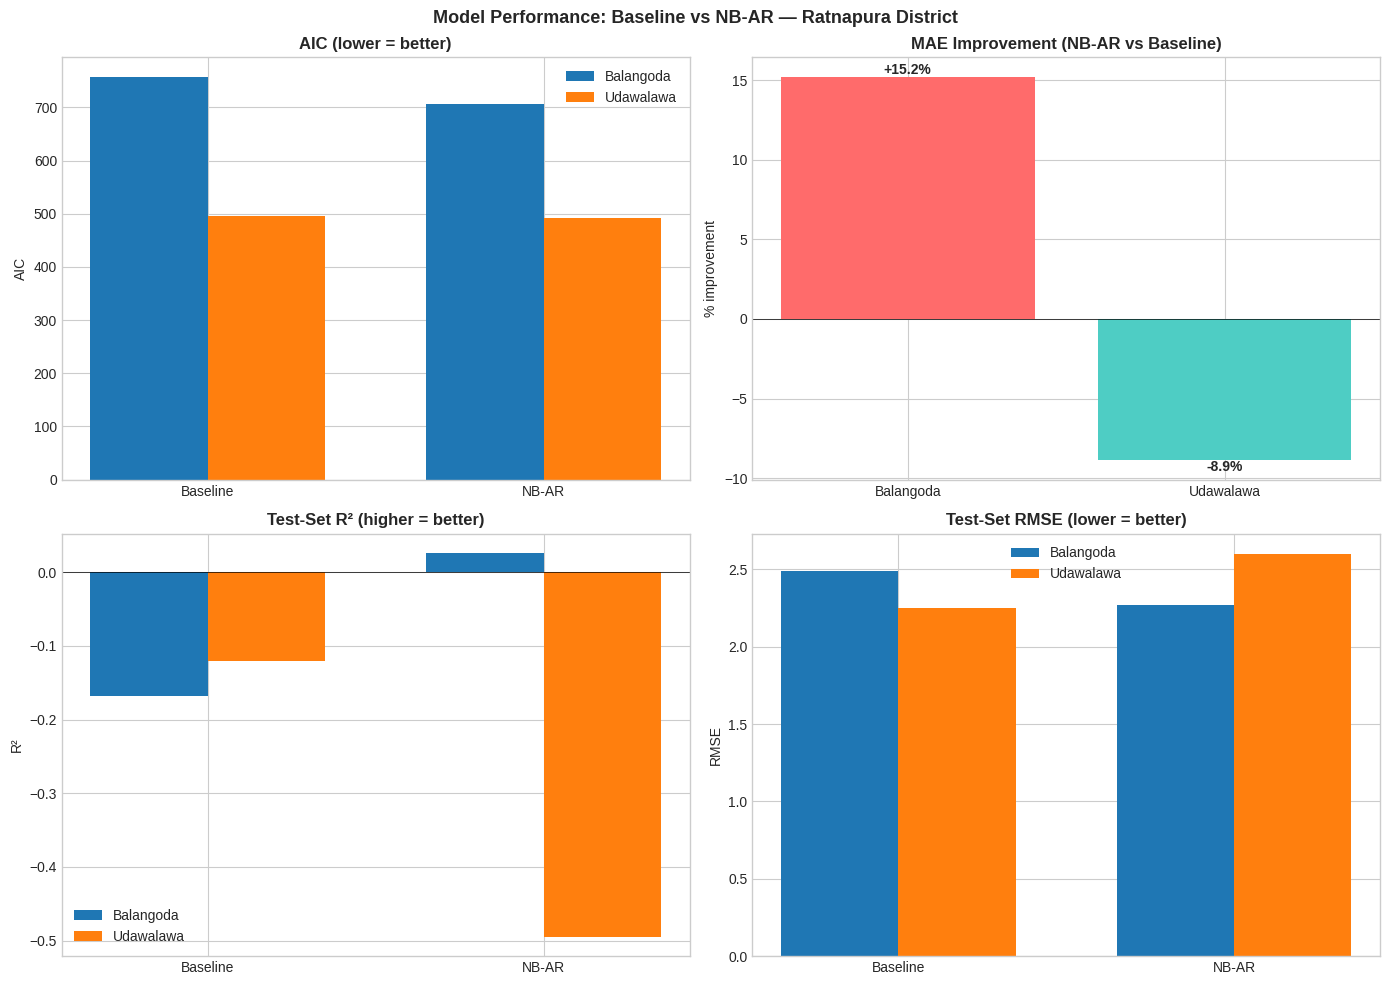

In [4]:
# Four-panel comparison figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance: Baseline vs NB-AR — Ratnapura District',
             fontsize=13, fontweight='bold')

# (a) AIC comparison
x = np.arange(2)
for i, moh in enumerate(['Balangoda','Udawalawa']):
    d = results[results['MOH']==moh].sort_values('Model')
    axes[0,0].bar(x + i*0.35, d['AIC'].values, 0.35, label=moh)
axes[0,0].set_xticks(x + 0.175)
axes[0,0].set_xticklabels(['Baseline','NB-AR'])
axes[0,0].set_title('AIC (lower = better)', fontweight='bold')
axes[0,0].set_ylabel('AIC'); axes[0,0].legend()

# (b) MAE improvement (percentage)
bl_mae = results[results['Model']=='Baseline'].sort_values('MOH')['MAE'].values
ar_mae = results[results['Model']=='NB-AR'].sort_values('MOH')['MAE'].values
improvement = (bl_mae - ar_mae) / bl_mae * 100
axes[0,1].bar(['Balangoda','Udawalawa'], improvement, color=['#FF6B6B','#4ECDC4'])
axes[0,1].set_title('MAE Improvement (NB-AR vs Baseline)', fontweight='bold')
axes[0,1].set_ylabel('% improvement')
axes[0,1].axhline(0, color='black', lw=0.5)
for i, v in enumerate(improvement):
    axes[0,1].text(i, v, f'{v:+.1f}%', ha='center',
                   va='bottom' if v>0 else 'top', fontweight='bold')

# (c) R² comparison
for i, moh in enumerate(['Balangoda','Udawalawa']):
    d = results[results['MOH']==moh].sort_values('Model')
    axes[1,0].bar(x + i*0.35, d['R2'].values, 0.35, label=moh)
axes[1,0].axhline(0, color='black', lw=0.5)
axes[1,0].set_xticks(x + 0.175)
axes[1,0].set_xticklabels(['Baseline','NB-AR'])
axes[1,0].set_title('Test-Set R² (higher = better)', fontweight='bold')
axes[1,0].set_ylabel('R²'); axes[1,0].legend()

# (d) RMSE comparison
for i, moh in enumerate(['Balangoda','Udawalawa']):
    d = results[results['MOH']==moh].sort_values('Model')
    axes[1,1].bar(x + i*0.35, d['RMSE'].values, 0.35, label=moh)
axes[1,1].set_xticks(x + 0.175)
axes[1,1].set_xticklabels(['Baseline','NB-AR'])
axes[1,1].set_title('Test-Set RMSE (lower = better)', fontweight='bold')
axes[1,1].set_ylabel('RMSE'); axes[1,1].legend()

plt.tight_layout()
plt.savefig('final_results_figure.png', dpi=300, bbox_inches='tight')
plt.savefig('final_results_figure.pdf', bbox_inches='tight')
plt.show()

## 7.5 Naive-Benchmark Summary

In [5]:
# Summarise how NB-AR compares to a naive 'predict last week' forecast
naive_rows = phase5[phase5['Model']=='Naive']
nbar_rows  = phase5[phase5['Model']=='NB-AR']
print('Naive vs NB-AR — MAE improvement:')
for moh in ['Balangoda','Udawalawa']:
    n_mae = naive_rows[naive_rows['MOH']==moh]['MAE'].values[0]
    a_mae = nbar_rows[nbar_rows['MOH']==moh]['MAE'].values[0]
    imp = (n_mae - a_mae) / n_mae * 100
    verdict = 'BEATS naive' if a_mae < n_mae else 'loses to naive'
    print(f'  {moh}: naive MAE = {n_mae:.3f}, NB-AR MAE = {a_mae:.3f}  → NB-AR {verdict} ({imp:+.1f}%)')

Naive vs NB-AR — MAE improvement:
  Balangoda: naive MAE = 2.000, NB-AR MAE = 1.575  → NB-AR BEATS naive (+21.3%)
  Udawalawa: naive MAE = 1.462, NB-AR MAE = 1.410  → NB-AR BEATS naive (+3.5%)


## 7.6 Cross-Validation Stability Summary

In [6]:
# Phase 6 five-fold CV summary per MOH
cv_summary = phase6.groupby('MOH').agg({
    'MAE':  ['mean','std'],
    'RMSE': ['mean','std'],
    'R2':   ['mean','std']
}).round(3)
print('Phase 6 — Cross-Validation Summary:')
print(cv_summary)
cv_summary.to_csv('phase7_cv_summary.csv')

Phase 6 — Cross-Validation Summary:
              MAE            RMSE                R2         
             mean     std    mean      std     mean      std
MOH                                                         
Balangoda  11.920  23.429  48.457  103.883 -250.058  558.809
Udawalawa   1.162   0.331   1.941    0.741   -0.224    0.315


## 7.7 Key Findings for the Thesis

In [9]:
# Generate summary text from the computed numbers (not hardcoded)
bl_bal  = results[(results['MOH']=='Balangoda') & (results['Model']=='Baseline')].iloc[0]
ar_bal  = results[(results['MOH']=='Balangoda') & (results['Model']=='NB-AR')].iloc[0]
bl_uda  = results[(results['MOH']=='Udawalawa') & (results['Model']=='Baseline')].iloc[0]
ar_uda  = results[(results['MOH']=='Udawalawa') & (results['Model']=='NB-AR')].iloc[0]

delta_aic_bal = bl_bal['AIC'] - ar_bal['AIC']
delta_aic_uda = bl_uda['AIC'] - ar_uda['AIC']
mae_imp_bal = (bl_bal['MAE'] - ar_bal['MAE']) / bl_bal['MAE'] * 100
mae_imp_uda = (bl_uda['MAE'] - ar_uda['MAE']) / bl_uda['MAE'] * 100

print('  KEY FINDINGS FOR THESIS (directly from computed CSVs)')
print(f'''
BALANGODA (wet zone):
  Baseline  AIC = {bl_bal["AIC"]:.2f}  MAE = {bl_bal["MAE"]:.3f}  R² = {bl_bal["R2"]:+.3f}
  NB-AR     AIC = {ar_bal["AIC"]:.2f}  MAE = {ar_bal["MAE"]:.3f}  R² = {ar_bal["R2"]:+.3f}
  ΔAIC = {delta_aic_bal:+.2f}  |  MAE improvement = {mae_imp_bal:+.1f}%

UDAWALAWA (dry zone):
  Baseline  AIC = {bl_uda["AIC"]:.2f}  MAE = {bl_uda["MAE"]:.3f}  R² = {bl_uda["R2"]:+.3f}
  NB-AR     AIC = {ar_uda["AIC"]:.2f}  MAE = {ar_uda["MAE"]:.3f}  R² = {ar_uda["R2"]:+.3f}
  ΔAIC = {delta_aic_uda:+.2f}  |  MAE improvement = {mae_imp_uda:+.1f}%
''')

  KEY FINDINGS FOR THESIS (directly from computed CSVs)

BALANGODA (wet zone):
  Baseline  AIC = 756.53  MAE = 1.858  R² = -0.167
  NB-AR     AIC = 706.37  MAE = 1.575  R² = +0.026
  ΔAIC = +50.16  |  MAE improvement = +15.2%

UDAWALAWA (dry zone):
  Baseline  AIC = 496.00  MAE = 1.295  R² = -0.120
  NB-AR     AIC = 492.61  MAE = 1.410  R² = -0.495
  ΔAIC = +3.39  |  MAE improvement = -8.9%



## 7.8 Download All Final Outputs

In [10]:
for f in ['final_model_results.csv','final_model_results.tex',
          'final_results_figure.png','final_results_figure.pdf',
          'phase7_cv_summary.csv']:
    try:
        files.download(f)
        print(f'Downloaded: {f}')
    except Exception:
        pass

print('  ALL PHASES COMPLETE — READY FOR THESIS SUBMISSION')
print('''
Deliverables:
  Phase 1  — Dengue data cleaning and validation
  Phase 2  — Rainfall integration (Weekly_Mean_Rainfall)
  Phase 2b — Lag feature engineering (rainfall, cumulative, autoregressive)
  Phase 3  — Exploratory data analysis
  Phase 4  — Formal statistical testing (Spearman, Granger, ADF, LR)
  Phase 5  — NB-AR modelling + naive benchmark + zone interaction test
  Phase 6  — Five-fold time-series cross-validation
  Phase 7  — Publication-ready results (computed, not hardcoded)
''')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: final_model_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: final_results_figure.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: phase7_cv_summary.csv
  ALL PHASES COMPLETE — READY FOR THESIS SUBMISSION

Deliverables:
  Phase 1  — Dengue data cleaning and validation
  Phase 2  — Rainfall integration (Weekly_Mean_Rainfall)
  Phase 2b — Lag feature engineering (rainfall, cumulative, autoregressive)
  Phase 3  — Exploratory data analysis
  Phase 4  — Formal statistical testing (Spearman, Granger, ADF, LR)
  Phase 5  — NB-AR modelling + naive benchmark + zone interaction test
  Phase 6  — Five-fold time-series cross-validation
  Phase 7  — Publication-ready results (computed, not hardcoded)

